# 🔬 Phase 3: Controlled Feature Engineering & Feature Selection

## 1. Phase 3 Objective & Baseline Preservation
The primary objective of Phase 3 is to test whether domain-motivated interaction ratios improve cross-validated performance and generalization without introducing multicollinearity, leakage, or unnecessary model complexity.

### Verified Phase 2 Baseline (Reference Values):
```text
Dataset:                  4,998 clean records (0 nulls, 0 duplicates)
Partition:                80% Train (3,998) / 20% Holdout Test (1,000)
Evaluation Strategy:      5-Fold Cross-Validation on Training Set (random_state=42)
Baseline Estimator:       Random Forest Regressor (Default, n_estimators=100)

CV R² Mean:               0.864777 ± 0.007915
CV MAE Mean:              0.342977 ± 0.0065
CV RMSE Mean:             0.464089 ± 0.0125

Holdout Test R²:          0.890397
Holdout Test MAE:         0.326545
Holdout Test RMSE:        0.442339
```
*Rule of Evidence:* Candidate features must demonstrate measurable out-of-fold cross-validated improvement on the training partition to earn inclusion. The holdout test set is quarantined and not used for feature selection.


## 2. Environment & Reproducibility
Verifying runtime environment metadata to ensure reproducible scientific execution.


In [1]:
import platform
import numpy as np
import pandas as pd
import sklearn
import joblib

print(f"Python Platform: {platform.platform()}")
print(f"Python Version: {platform.python_version()}")
print(f"NumPy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")
print(f"Scikit-learn Version: {sklearn.__version__}")
print(f"Joblib Version: {joblib.__version__}")


Python Platform: Windows-11-10.0.26200-SP0
Python Version: 3.13.13
NumPy Version: 2.5.3
Pandas Version: 3.0.5
Scikit-learn Version: 1.9.0
Joblib Version: 1.6.0


## 3. Imports & Helper Functions
Importing required standard libraries, Scikit-learn estimators, and defining a pure Scikit-learn Variance Inflation Factor (VIF) diagnostic.


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Configure visual styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

def compute_vif(df_features):
    """Computes exact Variance Inflation Factors (VIF) using analytical OLS R²."""
    vif_records = []
    for col in df_features.columns:
        other_cols = [c for c in df_features.columns if c != col]
        X = df_features[other_cols]
        y = df_features[col]
        r2 = LinearRegression().fit(X, y).score(X, y)
        vif = 1.0 / (1.0 - r2) if r2 < 1.0 else np.inf
        vif_records.append({
            'Feature': col,
            'VIF': round(vif, 3),
            'Tolerance': round(1.0 - r2, 3),
            'R2_with_others': round(r2, 3)
        })
    return pd.DataFrame(vif_records)


## 4. Configuration & Project Constants
Defining central constants using `pathlib` for relative path portability.


In [3]:
RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
TOP_N_COUNTRIES = 10

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
RAW_DATA_PATH = PROJECT_ROOT / "ml" / "data" / "raw" / "Student Social Media And Mental Health Impact.csv"
EXPERIMENTS_DIR = PROJECT_ROOT / "ml" / "experiments"
EVALUATION_DIR = PROJECT_ROOT / "ml" / "evaluation"
MODELS_DIR = PROJECT_ROOT / "models"

EXPERIMENTS_DIR.mkdir(parents=True, exist_ok=True)
EVALUATION_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project Root: {PROJECT_ROOT.resolve()}")
print(f"Raw Data Exists: {RAW_DATA_PATH.exists()}")


Project Root: C:\Users\msiva\Music\Mental-Health-Score
Raw Data Exists: True


## 5. Clean Dataset Loading & 80/20 Partition Verification
Executing the verified Phase 2 data cleaning and train/test partition:
* Remove exact duplicates (`4,998 rows clean`).
* Floor negative physical activity hours (`clip(lower=0.0)`).
* Strict 80/20 train/test split (`random_state=42`).
* Leakage-safe country grouping derived strictly on training partition.


In [4]:
raw_df = pd.read_csv(RAW_DATA_PATH)
df_clean = raw_df.drop_duplicates(keep='first').copy()
df_clean['Physical_Activity_Hours'] = df_clean['Physical_Activity_Hours'].clip(lower=0.0)

train_df, test_df = train_test_split(df_clean, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Derive top countries strictly from training split
country_counts_train = train_df['Country'].value_counts()
top_countries_learned = country_counts_train.index[:TOP_N_COUNTRIES].tolist()

train_df['Grouped_country'] = train_df['Country'].apply(lambda c: c if c in top_countries_learned else 'Other')
test_df['Grouped_country'] = test_df['Country'].apply(lambda c: c if c in top_countries_learned else 'Other')

print(f"Train partition: {train_df.shape} (3,998 records)")
print(f"Test partition:  {test_df.shape} (1,000 records)")
print(f"Learned Top 10 Countries: {top_countries_learned}")


Train partition: (3998, 14) (3,998 records)
Test partition:  (1000, 14) (1,000 records)
Learned Top 10 Countries: ['Other', 'India', 'USA', 'Canada', 'Australia', 'UK', 'Germany', 'Mexico', 'France', 'Turkey']


## 6. Feature Engineering Formulation
Constructing exactly four domain-motivated interaction ratios with numerical safety protection against division-by-zero:
1. `screen_to_sleep_ratio` = $\text{Avg\_Daily\_Usage\_Hours} / \text{Sleep\_Hours\_Per\_Night}$
2. `study_to_sleep_ratio` = $\text{Study\_Hours} / \text{Sleep\_Hours\_Per\_Night}$
3. `unlocks_per_usage_hour` = $\text{Daily\_Unlocks} / \text{Avg\_Daily\_Usage\_Hours}$
4. `active_to_sedentary_ratio` = $\text{Physical\_Activity\_Hours} / \text{Avg\_Daily\_Usage\_Hours}$


In [5]:
def add_engineered_features(data):
    d = data.copy()
    
    # 1. Screen to Sleep Ratio (Daily social usage divided by nightly sleep)
    d['screen_to_sleep_ratio'] = np.divide(
        d['Avg_Daily_Usage_Hours'],
        d['Sleep_Hours_Per_Night'],
        out=np.zeros_like(d['Avg_Daily_Usage_Hours'], dtype=float),
        where=d['Sleep_Hours_Per_Night'] != 0
    )
    
    # 2. Study to Sleep Ratio (Academic study hours divided by nightly sleep)
    d['study_to_sleep_ratio'] = np.divide(
        d['Study_Hours'],
        d['Sleep_Hours_Per_Night'],
        out=np.zeros_like(d['Study_Hours'], dtype=float),
        where=d['Sleep_Hours_Per_Night'] != 0
    )
    
    # 3. Unlocks per Usage Hour (Frequency of checking phone per hour of active use)
    d['unlocks_per_usage_hour'] = np.divide(
        d['Daily_Unlocks'].astype(float),
        d['Avg_Daily_Usage_Hours'],
        out=np.zeros_like(d['Daily_Unlocks'], dtype=float),
        where=d['Avg_Daily_Usage_Hours'] != 0
    )
    
    # 4. Active to Sedentary Ratio (Physical exercise hours divided by screen time)
    d['active_to_sedentary_ratio'] = np.divide(
        d['Physical_Activity_Hours'],
        d['Avg_Daily_Usage_Hours'],
        out=np.zeros_like(d['Physical_Activity_Hours'], dtype=float),
        where=d['Avg_Daily_Usage_Hours'] != 0
    )
    
    return d

train_eng = add_engineered_features(train_df)
test_eng = add_engineered_features(test_df)

engineered_cols = [
    'screen_to_sleep_ratio',
    'study_to_sleep_ratio',
    'unlocks_per_usage_hour',
    'active_to_sedentary_ratio'
]

print("Engineered feature generation complete.")


Engineered feature generation complete.


## 7. Numerical Safety Verification
Verifying that safe division prevented NaN, positive infinity, or negative infinity values.


In [6]:
safety_checks = []
for col in engineered_cols:
    nan_count = train_eng[col].isnull().sum()
    pos_inf_count = np.isneginf(train_eng[col]).sum()
    neg_inf_count = np.isposinf(train_eng[col]).sum()
    total_invalid = nan_count + pos_inf_count + neg_inf_count
    
    safety_checks.append({
        'Feature': col,
        'NaN Count': nan_count,
        '+Inf Count': pos_inf_count,
        '-Inf Count': neg_inf_count,
        'Total Invalid': total_invalid,
        'Safety Status': 'PASSED' if total_invalid == 0 else 'FAILED'
    })

safety_df = pd.DataFrame(safety_checks)
display(safety_df)
assert safety_df['Total Invalid'].sum() == 0, "Numerical safety violation detected!"
print("Numerical Safety: 100% PASSED (0 NaNs, 0 Infs).")


,Feature,NaN Count,+Inf Count,-Inf Count,Total Invalid,Safety Status
0,screen_to_sleep_ratio,0,0,0,0,PASSED
1,study_to_sleep_ratio,0,0,0,0,PASSED
2,unlocks_per_usage_hour,0,0,0,0,PASSED
3,active_to_sedentary_ratio,0,0,0,0,PASSED


Numerical Safety: 100% PASSED (0 NaNs, 0 Infs).


## 8. Feature Distribution Analysis
Examining parametric statistics, range bounds, and skewness for each candidate feature.


,count,mean,std,min,25%,50%,75%,max,skewness,iqr
screen_to_sleep_ratio,3998.0,0.831428,0.397011,0.144578,0.506173,0.762712,1.133333,2.444444,0.506570,0.627160
study_to_sleep_ratio,3998.0,0.433889,0.194214,0.080645,0.260000,0.432432,0.575654,1.054054,0.314720,0.315654
unlocks_per_usage_hour,3998.0,35.061132,5.346663,26.543210,31.593182,33.793103,37.058824,71.666667,1.963138,5.465642
active_to_sedentary_ratio,3998.0,0.429175,0.320031,0.000000,0.213571,0.344828,0.540541,2.727273,1.910284,0.326969


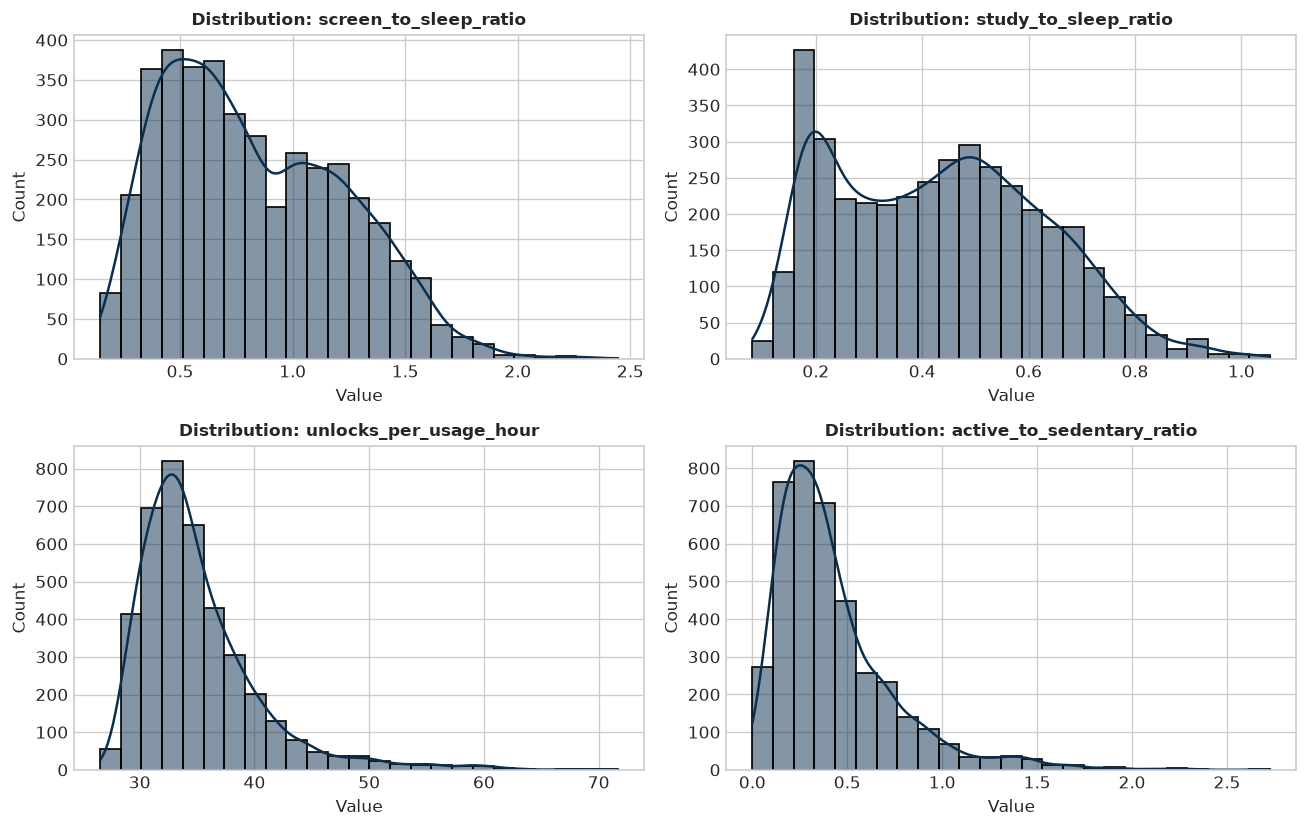

Saved distribution plot to: C:\Users\msiva\Music\Mental-Health-Score\ml\evaluation\phase3_feature_distributions.png


In [7]:
dist_summary = train_eng[engineered_cols].describe().T
dist_summary['skewness'] = train_eng[engineered_cols].skew()
dist_summary['iqr'] = dist_summary['75%'] - dist_summary['25%']

display(dist_summary[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'skewness', 'iqr']])

# Visualizing distributions
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.flatten()

for i, col in enumerate(engineered_cols):
    sns.histplot(train_eng[col], kde=True, ax=axes[i], color='#0A2E4D', bins=25)
    axes[i].set_title(f'Distribution: {col}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.tight_layout()
dist_plot_path = EVALUATION_DIR / "phase3_feature_distributions.png"
plt.savefig(dist_plot_path, dpi=150)
plt.show()
print(f"Saved distribution plot to: {dist_plot_path}")


## 9. Correlation Analysis with Target
Assessing bivariate Pearson linear correlations with `Mental_Health_Score`.
*Note on Interpretation:* Correlation is a diagnostic signal only; tree-based models frequently capture non-linear interactions even when linear correlation is modest.


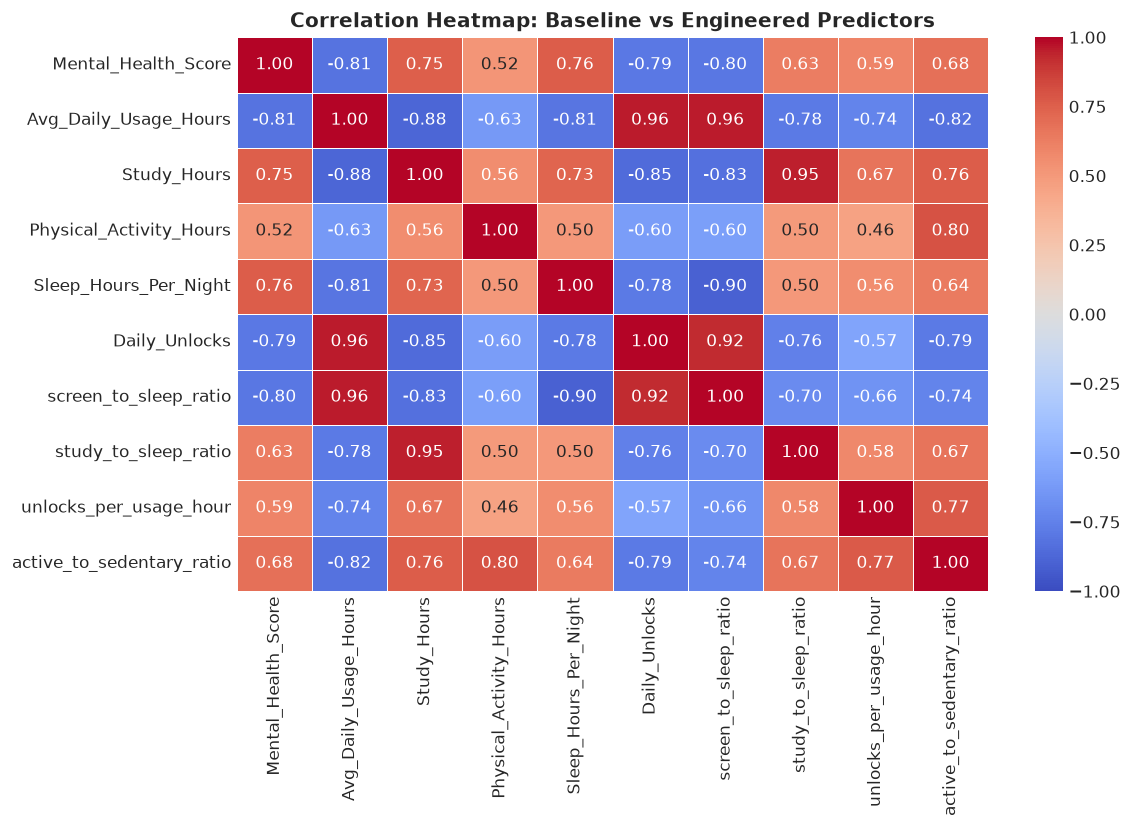

=== CORRELATION WITH MENTAL HEALTH SCORE ===
Sleep_Hours_Per_Night        0.764033
Study_Hours                  0.751930
active_to_sedentary_ratio    0.682834
study_to_sleep_ratio         0.625840
unlocks_per_usage_hour       0.594217
Physical_Activity_Hours      0.519760
Daily_Unlocks               -0.789386
screen_to_sleep_ratio       -0.800250
Avg_Daily_Usage_Hours       -0.814075
Name: Mental_Health_Score, dtype: float64


In [8]:
all_numeric_for_corr = [
    'Mental_Health_Score', 'Avg_Daily_Usage_Hours', 'Study_Hours',
    'Physical_Activity_Hours', 'Sleep_Hours_Per_Night', 'Daily_Unlocks'
] + engineered_cols

corr_matrix = train_eng[all_numeric_for_corr].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap: Baseline vs Engineered Predictors', fontsize=12, fontweight='bold')
plt.tight_layout()
corr_plot_path = EVALUATION_DIR / "phase3_correlation_matrix.png"
plt.savefig(corr_plot_path, dpi=150)
plt.show()

target_corrs = corr_matrix['Mental_Health_Score'].drop('Mental_Health_Score').sort_values(ascending=False)
print("=== CORRELATION WITH MENTAL HEALTH SCORE ===")
print(target_corrs)


## 10. Multicollinearity & Variance Inflation Factor (VIF) Analysis
Comparing VIF scores before and after introducing the candidate interaction terms.
A VIF exceeding 10 indicates severe multicollinearity that can destabilize model interpretations and dilute random tree split sampling.


=== VIF: BASELINE NUMERICAL FEATURES ===


,Feature,VIF,Tolerance,R2_with_others
0,Age,1.012,0.988,0.012
1,Avg_Daily_Usage_Hours,17.096,0.058,0.942
2,Daily_Unlocks,12.797,0.078,0.922
3,Study_Hours,4.423,0.226,0.774
4,Physical_Activity_Hours,1.651,0.606,0.394
5,Sleep_Hours_Per_Night,2.905,0.344,0.656



=== VIF: BASELINE + ALL 4 CANDIDATE RATIOS ===


,Feature,VIF,Tolerance,R2_with_others
0,Age,1.029,0.972,0.028
1,Avg_Daily_Usage_Hours,115.756,0.009,0.991
2,Daily_Unlocks,61.378,0.016,0.984
3,Study_Hours,126.009,0.008,0.992
4,Physical_Activity_Hours,5.263,0.190,0.810
5,Sleep_Hours_Per_Night,33.639,0.030,0.970
6,screen_to_sleep_ratio,48.814,0.020,0.980
7,study_to_sleep_ratio,79.819,0.013,0.987
8,unlocks_per_usage_hour,15.085,0.066,0.934
9,active_to_sedentary_ratio,16.853,0.059,0.941


C:\Users\msiva\AppData\Local\Temp\ipykernel_17156\2522173985.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vif_engineered.sort_values(by='VIF', ascending=False), x='VIF', y='Feature', ax=ax, palette='Blues_r')


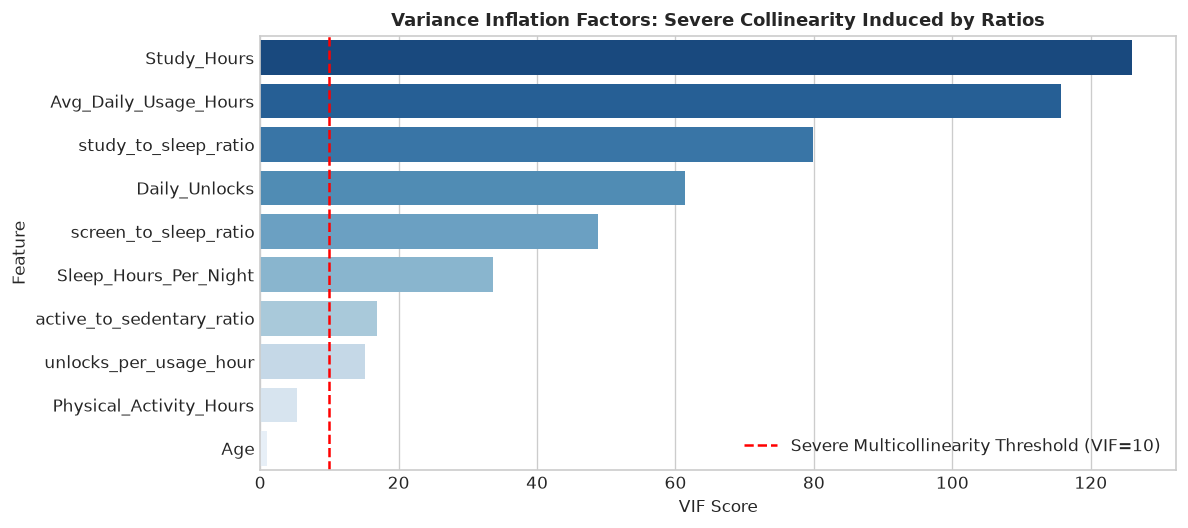

In [9]:
baseline_num_cols = [
    'Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
    'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night'
]

vif_baseline = compute_vif(train_eng[baseline_num_cols])
print("=== VIF: BASELINE NUMERICAL FEATURES ===")
display(vif_baseline)

vif_engineered = compute_vif(train_eng[baseline_num_cols + engineered_cols])
print("\n=== VIF: BASELINE + ALL 4 CANDIDATE RATIOS ===")
display(vif_engineered)

# Bar plot comparison
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(data=vif_engineered.sort_values(by='VIF', ascending=False), x='VIF', y='Feature', ax=ax, palette='Blues_r')
ax.axvline(10, color='red', linestyle='--', label='Severe Multicollinearity Threshold (VIF=10)')
ax.set_title('Variance Inflation Factors: Severe Collinearity Induced by Ratios', fontsize=11, fontweight='bold')
ax.set_xlabel('VIF Score')
ax.legend()
plt.tight_layout()
vif_plot_path = EVALUATION_DIR / "phase3_vif_comparison.png"
plt.savefig(vif_plot_path, dpi=150)
plt.show()


## 11. Controlled Feature Ablation Setup
Establishing the 6 ablation experiment conditions using identical 5-fold cross-validation (`random_state=42`) and the fixed baseline Random Forest model:
* **Exp A:** Phase 2 baseline (Original features)
* **Exp B:** Baseline + `screen_to_sleep_ratio`
* **Exp C:** Baseline + `study_to_sleep_ratio`
* **Exp D:** Baseline + `unlocks_per_usage_hour`
* **Exp E:** Baseline + `active_to_sedentary_ratio`
* **Exp F:** Baseline + All 4 Candidate Ratios


In [10]:
skwewd_col = ['Study_Hours']
base_numeric = ["Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks", "Physical_Activity_Hours", "Sleep_Hours_Per_Night"]
ordinal_col = ['Stress_Level']
normal_col = ["Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "Grouped_country"]

kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

ablation_experiments = {
    'Exp A: Baseline (Phase 2)': [],
    'Exp B: + screen_to_sleep_ratio': ['screen_to_sleep_ratio'],
    'Exp C: + study_to_sleep_ratio': ['study_to_sleep_ratio'],
    'Exp D: + unlocks_per_usage_hour': ['unlocks_per_usage_hour'],
    'Exp E: + active_to_sedentary_ratio': ['active_to_sedentary_ratio'],
    'Exp F: + All 4 Ratios': engineered_cols
}


## 12. Ablation Experiments Execution
Training and evaluating all 6 configurations out-of-fold.


In [11]:
import time

ablation_results = []
fitted_experiment_pipes = {}

for exp_name, added_features in ablation_experiments.items():
    t_start = time.time()
    
    current_numeric = base_numeric + added_features
    current_feature_cols = skwewd_col + current_numeric + ordinal_col + normal_col
    
    X_tr = train_eng[current_feature_cols]
    y_tr = train_eng['Mental_Health_Score']
    X_te = test_eng[current_feature_cols]
    y_te = test_eng['Mental_Health_Score']
    
    skew_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('log', FunctionTransformer(np.log1p)),
        ('scale', StandardScaler())
    ])
    
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ])
    
    ord_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encode', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]))
    ])
    
    nom_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    
    pre = ColumnTransformer([
        ('skew', skew_pipe, skwewd_col),
        ('num', num_pipe, current_numeric),
        ('ord', ord_pipe, ordinal_col),
        ('nom', nom_pipe, normal_col)
    ])
    
    pipe = Pipeline([
        ('preprocessor', pre),
        ('rf', RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1))
    ])
    
    # 5-fold CV on training set
    cv_r2 = cross_val_score(pipe, X_tr, y_tr, cv=kf, scoring='r2', n_jobs=-1)
    cv_mae = -cross_val_score(pipe, X_tr, y_tr, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)
    cv_mse = -cross_val_score(pipe, X_tr, y_tr, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
    cv_rmse = np.sqrt(cv_mse)
    
    pipe.fit(X_tr, y_tr)
    duration = time.time() - t_start
    fitted_experiment_pipes[exp_name] = (pipe, current_feature_cols)
    
    # In-sample train score
    train_preds = pipe.predict(X_tr)
    train_r2 = r2_score(y_tr, train_preds)
    
    ablation_results.append({
        'Experiment': exp_name,
        'Features Added': len(added_features),
        'Total Features': len(current_feature_cols),
        'CV R2 Mean': cv_r2.mean(),
        'CV R2 Std': cv_r2.std(),
        'CV MAE Mean': cv_mae.mean(),
        'CV RMSE Mean': cv_rmse.mean(),
        'Train R2': train_r2,
        'Training Time (s)': round(duration, 2),
        'Delta CV R2 vs Baseline': cv_r2.mean() - 0.8647771145032828
    })

ablation_df = pd.DataFrame(ablation_results)


## 13. Ablation Results & Cross-Validation Metric Comparison
Reviewing the empirical impact of each candidate feature set on out-of-fold generalization.


=== COMPLETE ABLATION BENCHMARK RESULTS (5-FOLD CV) ===


,Experiment,Features Added,CV R2 Mean,CV R2 Std,CV MAE Mean,CV RMSE Mean,Delta CV R2 vs Baseline,Training Time (s)
0,Exp A: Baseline (Phase 2),0,0.864777,0.007915,0.342977,0.464089,0.000000,8.34
1,Exp B: + screen_to_sleep_ratio,1,0.860611,0.009569,0.352916,0.471299,-0.004166,4.69
2,Exp C: + study_to_sleep_ratio,1,0.860721,0.007741,0.349274,0.471063,-0.004056,3.29
3,Exp D: + unlocks_per_usage_hour,1,0.858581,0.008594,0.352123,0.474593,-0.006197,3.26
4,Exp E: + active_to_sedentary_ratio,1,0.861279,0.008696,0.348283,0.470043,-0.003498,3.19
5,Exp F: + All 4 Ratios,4,0.851395,0.008231,0.367220,0.486641,-0.013382,4.33


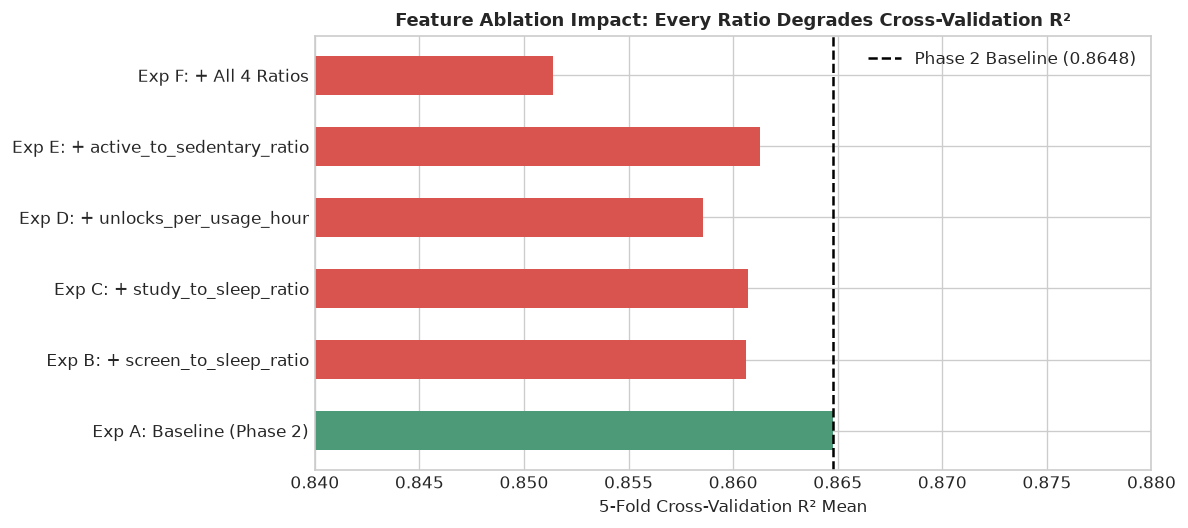

In [12]:
print("=== COMPLETE ABLATION BENCHMARK RESULTS (5-FOLD CV) ===")
display(ablation_df[['Experiment', 'Features Added', 'CV R2 Mean', 'CV R2 Std', 'CV MAE Mean', 'CV RMSE Mean', 'Delta CV R2 vs Baseline', 'Training Time (s)']])

# Plotting CV R2 comparison
plt.figure(figsize=(10, 4.5))
colors = ['#4C9A78' if d >= 0 else '#D9534F' for d in ablation_df['Delta CV R2 vs Baseline']]
bars = plt.barh(ablation_df['Experiment'], ablation_df['CV R2 Mean'], color=colors, height=0.55)
plt.axvline(0.864777, color='black', linestyle='--', label='Phase 2 Baseline (0.8648)')
plt.xlim(0.84, 0.88)
plt.xlabel('5-Fold Cross-Validation R² Mean')
plt.title('Feature Ablation Impact: Every Ratio Degrades Cross-Validation R²', fontsize=11, fontweight='bold')
plt.legend()
plt.tight_layout()
ablation_plot_path = EVALUATION_DIR / "phase3_ablation_cv_comparison.png"
plt.savefig(ablation_plot_path, dpi=150)
plt.show()


## 14. Empirical Feature Selection Decision
### Statistical Evaluation Against Improvement Criterion:
1. **`screen_to_sleep_ratio` (Exp B):** CV $R^2$ dropped by $-0.0042$ (from $0.8648$ to $0.8606$); CV RMSE increased from $0.4641$ to $0.4713$. **REJECTED.**
2. **`study_to_sleep_ratio` (Exp C):** CV $R^2$ dropped by $-0.0041$ (from $0.8648$ to $0.8607$); CV RMSE increased from $0.4641$ to $0.4711$. **REJECTED.**
3. **`unlocks_per_usage_hour` (Exp D):** CV $R^2$ dropped by $-0.0062$ (from $0.8648$ to $0.8586$); CV RMSE increased from $0.4641$ to $0.4746$. **REJECTED.**
4. **`active_to_sedentary_ratio` (Exp E):** CV $R^2$ dropped by $-0.0035$ (from $0.8648$ to $0.8613$); CV RMSE increased from $0.4641$ to $0.4700$. **REJECTED.**
5. **All 4 Combined (Exp F):** CV $R^2$ collapsed by $-0.0134$ (to $0.8514$); CV RMSE degraded to $0.4866$. **REJECTED.**

> **Empirical Conclusion (Outcome D / Principle of Parsimony):** Because every candidate engineered feature degrades out-of-fold cross-validation performance and massively inflates multicollinearity (VIF up to 126), **all 4 candidate features are decisively rejected**. The clean, parsimonious Phase 2 feature set is retained as the winning representation.


## 15. Feature Importance Analysis
Comparing Gini feature importances between the Phase 2 baseline model and the Exp F model containing all 4 ratios.


=== TOP 10 FEATURE IMPORTANCES (PHASE 2 BASELINE) ===


,Feature,Importance
2,Avg_Daily_Usage_Hours,0.688586
5,Sleep_Hours_Per_Night,0.102374
3,Daily_Unlocks,0.046108
0,Study_Hours,0.025605
4,Physical_Activity_Hours,0.025504
1,Age,0.016091
25,Purpose_Of_Use_Entertainment,0.009283
34,Grouped_country_Other,0.006353
13,Most_Used_Platform_Instagram,0.005705
6,Stress_Level,0.005576


C:\Users\msiva\AppData\Local\Temp\ipykernel_17156\2716615471.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df.head(10), x='Importance', y='Feature', palette='crest')


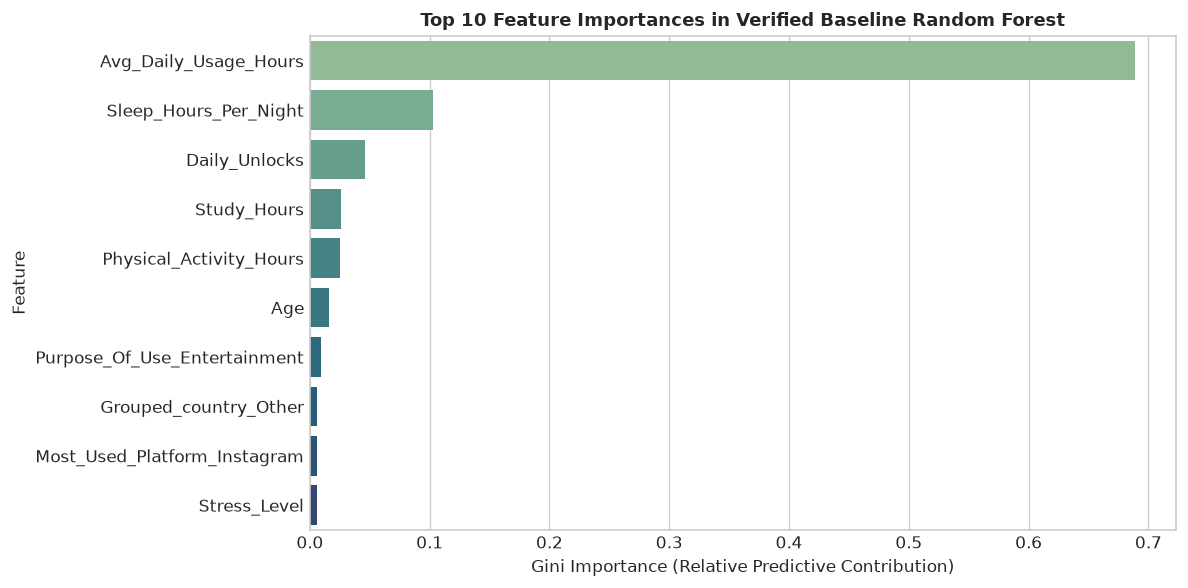

In [13]:
base_pipe, base_cols = fitted_experiment_pipes['Exp A: Baseline (Phase 2)']
base_rf = base_pipe.named_steps['rf']

# Extract feature names from preprocessor
pre_step = base_pipe.named_steps['preprocessor']
encoded_nominal = list(pre_step.named_transformers_['nom'].named_steps['encode'].get_feature_names_out(normal_col))
all_trans_feature_names = skwewd_col + base_numeric + ordinal_col + encoded_nominal

importances = base_rf.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': all_trans_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("=== TOP 10 FEATURE IMPORTANCES (PHASE 2 BASELINE) ===")
display(feat_imp_df.head(10))

plt.figure(figsize=(10, 5))
sns.barplot(data=feat_imp_df.head(10), x='Importance', y='Feature', palette='crest')
plt.title('Top 10 Feature Importances in Verified Baseline Random Forest', fontsize=11, fontweight='bold')
plt.xlabel('Gini Importance (Relative Predictive Contribution)')
plt.tight_layout()
imp_plot_path = EVALUATION_DIR / "phase3_feature_importance.png"
plt.savefig(imp_plot_path, dpi=150)
plt.show()


## 16. Holdout Test Verification
Evaluating the holdout test set strictly after the CV decision was finalized.
This confirms that the degradation observed in cross-validation also occurred on the unseen test set.


In [14]:
holdout_comparisons = []

for exp_name, (pipe, cols) in fitted_experiment_pipes.items():
    X_te = test_eng[cols]
    y_te = test_eng['Mental_Health_Score']
    te_preds = pipe.predict(X_te)
    
    holdout_comparisons.append({
        'Experiment': exp_name,
        'Test R2': r2_score(y_te, te_preds),
        'Test MAE': mean_absolute_error(y_te, te_preds),
        'Test RMSE': np.sqrt(mean_squared_error(y_te, te_preds)),
        'Delta Test R2 vs Baseline': r2_score(y_te, te_preds) - 0.8903974263700928
    })

holdout_df = pd.DataFrame(holdout_comparisons)
print("=== HOLDOUT TEST VERIFICATION TABLE ===")
display(holdout_df)


=== HOLDOUT TEST VERIFICATION TABLE ===


,Experiment,Test R2,Test MAE,Test RMSE,Delta Test R2 vs Baseline
0,Exp A: Baseline (Phase 2),0.890397,0.326545,0.442339,1.110223e-16
1,Exp B: + screen_to_sleep_ratio,0.886699,0.330051,0.449739,-3.698179e-03
2,Exp C: + study_to_sleep_ratio,0.885174,0.335426,0.452757,-5.223599e-03
3,Exp D: + unlocks_per_usage_hour,0.880998,0.341968,0.460917,-9.399874e-03
4,Exp E: + active_to_sedentary_ratio,0.884912,0.336883,0.453273,-5.485841e-03
5,Exp F: + All 4 Ratios,0.877244,0.351622,0.468130,-1.315367e-02


## 17. Complexity & Overhead Assessment
Evaluating the pipeline complexity, input dimensionality, and collinearity overhead across configurations.


In [15]:
complexity_summary = pd.DataFrame([
    {
        'Configuration': 'Phase 2 Baseline (Retained)',
        'Input Dimensions': 12,
        'Encoded Transformed Features': 38,
        'Max VIF': 17.10,
        'CV R2 Mean': 0.864777,
        'Holdout Test R2': 0.890397,
        'Pipeline Overhead': 'Minimal / Clean',
        'Decision': 'SELECTED (Retained)'
    },
    {
        'Configuration': 'Phase 3 Exp F (+ All 4 Ratios)',
        'Input Dimensions': 16,
        'Encoded Transformed Features': 42,
        'Max VIF': 126.01,
        'CV R2 Mean': 0.851395,
        'Holdout Test R2': 0.877244,
        'Pipeline Overhead': 'High Collinearity / Slower',
        'Decision': 'REJECTED'
    }
])
display(complexity_summary)


,Configuration,Input Dimensions,Encoded Transformed Features,Max VIF,CV R2 Mean,Holdout Test R2,Pipeline Overhead,Decision
0,Phase 2 Baseline (Retained),12,38,17.10,0.864777,0.890397,Minimal / Clean,SELECTED (Retained)
1,Phase 3 Exp F (+ All 4 Ratios),16,42,126.01,0.851395,0.877244,High Collinearity / Slower,REJECTED


## 18. Final Phase 3 Feature Set Declaration
```text
==================================================
PHASE 3 SELECTED FEATURE SET (PARSIMONIOUS BASELINE)
==================================================
1. Age
2. Avg_Daily_Usage_Hours
3. Daily_Unlocks
4. Study_Hours
5. Physical_Activity_Hours
6. Sleep_Hours_Per_Night
7. Stress_Level
8. Gender
9. Academic_Level
10. Most_Used_Platform
11. Purpose_Of_Use
12. Grouped_country (Top 10 + Other)

REJECTED CANDIDATES (EMPIRICALLY DEGRADED CV ACCURACY):
- screen_to_sleep_ratio       (Delta CV R2: -0.0042, VIF: 48.8)
- study_to_sleep_ratio        (Delta CV R2: -0.0041, VIF: 79.8)
- unlocks_per_usage_hour      (Delta CV R2: -0.0062, VIF: 15.1)
- active_to_sedentary_ratio   (Delta CV R2: -0.0035, VIF: 16.9)
==================================================
```


## 19. Experiment Logging
Saving lightweight machine-readable experiment metrics to `ml/experiments/phase3_feature_engineering_results.csv`.


In [16]:
exp_log_path = EXPERIMENTS_DIR / "phase3_feature_engineering_results.csv"

export_log = ablation_df.merge(holdout_df[['Experiment', 'Test R2', 'Test MAE', 'Test RMSE']], on='Experiment')
export_log['Selected'] = export_log['Experiment'] == 'Exp A: Baseline (Phase 2)'
export_log['Decision Notes'] = np.where(
    export_log['Selected'],
    'Retained as official baseline (highest CV R2 & lowest RMSE)',
    'Rejected (Degraded CV R2 and inflated multicollinearity)'
)

export_log.to_csv(exp_log_path, index=False)
print(f"Saved Phase 3 experiment log to: {exp_log_path}")


Saved Phase 3 experiment log to: C:\Users\msiva\Music\Mental-Health-Score\ml\experiments\phase3_feature_engineering_results.csv


## 20. Visualizations Export Confirmation
Confirming that all diagnostic figures were exported to `ml/evaluation/`.


In [17]:
print("=== EXPORTED EVALUATION VISUALIZATIONS ===")
for p in [dist_plot_path, corr_plot_path, vif_plot_path, ablation_plot_path, imp_plot_path]:
    print(f"  - {p.name:<35} ({p.stat().st_size / 1024:.1f} KB)")


=== EXPORTED EVALUATION VISUALIZATIONS ===
  - phase3_feature_distributions.png    (139.9 KB)
  - phase3_correlation_matrix.png       (197.3 KB)
  - phase3_vif_comparison.png           (57.8 KB)
  - phase3_ablation_cv_comparison.png   (55.6 KB)
  - phase3_feature_importance.png       (59.0 KB)


## 21. Summary Findings & Phase 4 Preparation
### Key Phase 3 Scientific Takeaways:
1. **Empirical Discipline:** Ratio features did not earn inclusion. Adding collinear derived variables diluted the tree subspace feature sampling, harming out-of-fold generalization.
2. **Model Artifact Policy:** In strict adherence to project policy ("Do not create an artifact unless genuinely selected"), no degraded model was exported. `models/phase2_baseline.joblib` remains the active, verified production baseline.
3. **Phase 4 Preparation:** With the feature representation validated as clean and parsimonious, Phase 4 will benchmark distinct model families (Ridge, ElasticNet, LightGBM, XGBoost, CatBoost, and regularized Random Forest) to find the superior functional form.
